In [7]:
import torch
import torch.nn.functional as F

import torch
import torch.nn.functional as F


def fractal_dimension_map_2d(img: torch.Tensor,
                             threshold: float = None,
                             eps_list=(9, 27, 81),
                             window_size=81,
                             eps_small=1e-8):

    assert img.dim() == 2
    device = img.device
    dtype = torch.float32

    x = img.to(dtype).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

    if threshold is not None:
        x = (x > threshold).float()

    H, W = img.shape
    counts = []

    for eps in eps_list:

        # 1️⃣ огрубление
        pooled = F.max_pool2d(x, kernel_size=eps, stride=eps)

        # 2️⃣ бинаризация занятых боксов
        occupied = (pooled > 0).float()

        # 3️⃣ считаем количество боксов в 81×81 окне
        k = window_size // eps  # размер окна в coarse-сетке

        # паддинг чтобы вернуть исходный размер
        pad = k // 2

        # свёртка единичным ядром
        kernel = torch.ones((1, 1, k, k), device=device)
        local_count = F.conv2d(occupied, kernel, padding=pad)

        # upscale обратно к размеру H×W
        up = F.interpolate(local_count,
                           size=(H, W),
                           mode='nearest')

        counts.append(up.squeeze(0).squeeze(0))

    # stack: (3, H, W)
    N_eps = torch.stack(counts, dim=0)

    # логарифмы
    log_N = torch.log(N_eps + eps_small)

    log_eps = torch.log(torch.tensor(eps_list,
                                     dtype=dtype,
                                     device=device)).view(-1, 1, 1)

    x_mean = log_eps.mean()
    var_x = ((log_eps - x_mean) ** 2).sum()

    y_mean = log_N.mean(dim=0, keepdim=True)

    cov = ((log_eps - x_mean) * (log_N - y_mean)).sum(dim=0)

    slope = cov / var_x

    D = -slope

    return D

In [5]:
import torch
import rasterio as rs
from pathlib import Path

device = torch.device("cuda")


raster_path = Path(r"D:\ml_datasets\Chukotka\DEM\Линеаменты растр (полные)\растр линеаментов 120m.tif")
tensor = torch.tensor(rs.open(raster_path).read()).to(device)
tensor.shape

torch.Size([1, 6253, 9277])

In [14]:
import numpy as np

np.percentile(tensor.cpu(), 50)

np.float64(186.0)

In [15]:
result = fractal_dimension_map_2d(tensor[0], threshold=180)

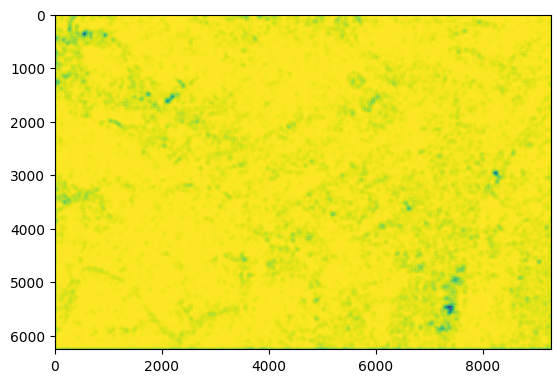

In [16]:
import matplotlib.pyplot as plt

plt.imshow(result.cpu())

In [17]:
ds = torch.tensor(
    rs.open(r"D:\ml_datasets\Chukotka\Landsat_raw\indicies\Ferric_iron,_Fe3+.tif").read(1)
).to(device)

In [21]:
np.nanpercentile(ds.cpu(), 50)

np.float32(1.0025606)

In [27]:
result = fractal_dimension_map_2d(ds[::10, ::10], threshold=1)

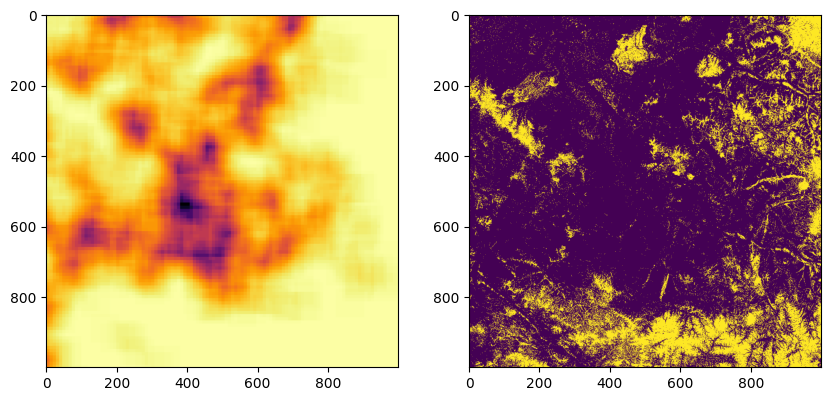

In [43]:
fig, ax = plt.subplots(1,2, figsize=(10,10))

ax[0].imshow(result.cpu()[1000:2000, 1000:2000],cmap="inferno")
ax[1].imshow(ds.cpu()[::10, ::10][1000:2000, 1000:2000] > 1)

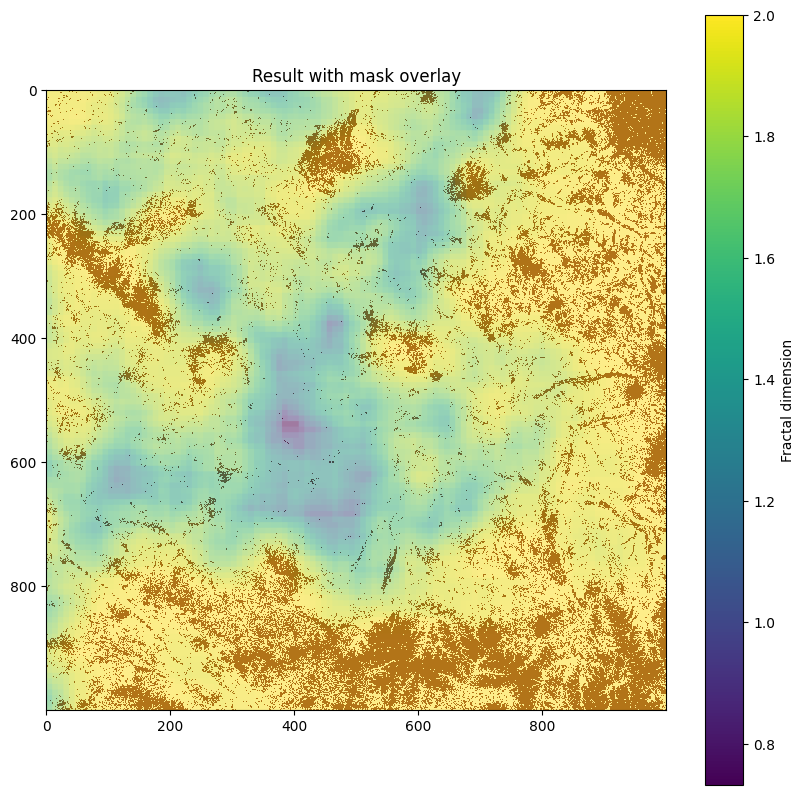

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Предположим, result и ds — уже тензоры на CPU (или GPU, тогда нужно .cpu())
# Вырежем нужные фрагменты
result_slice = result.cpu()[1000:2000, 1000:2000]          # непрерывное изображение
mask_slice = ds.cpu()[::10, ::10][1000:2000, 1000:2000] > 1   # бинарная маска

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Показываем основное изображение
im = ax.imshow(result_slice, cmap='viridis')

# Вариант 1: накладываем маску полупрозрачным цветом через второй imshow
# Для бинарной маски используем цветовую карту с альфа-каналом
ax.imshow(mask_slice, cmap='Reds', alpha=0.5, interpolation='none')

# Вариант 2 (более гибкий): создаём RGBA-слой вручную
# mask_rgba = np.zeros((*mask_slice.shape, 4))
# mask_rgba[mask_slice] = [1, 0, 0, 0.5]   # красный с прозрачностью 0.5
# ax.imshow(mask_rgba)

plt.colorbar(im, ax=ax, label='Fractal dimension')
ax.set_title('Result with mask overlay')
plt.show()